# Day 30 - Finding the Ideal Number of Customer Segments
60 Days Data Science | Phase: Clustering Optimization

**Date:** 12 June 2026  
**Name:** Rajesh Yadav

---

so today is day 30, the final day of the clustering segment. 
yesterday i built a basic k-means model with 5 clusters. today i am going to systematically find the optimal number of clusters using two standard validation methods:
1. **the elbow method** (wcss/inertia)
2. **silhouette score analysis** (checking how well-separated the clusters are)

i will compare different K values, visualize the differences, and document why K=5 is indeed the best balance between math and business logic.


## step 1 - imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print("pandas:", pd.__version__)
print("numpy:", np.__version__)


pandas: 2.2.3
numpy: 2.2.1


## step 2 - load dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")
print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


## step 3 - select features

In [3]:
# we use annual income and spending score for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


## step 4 - standard scaling

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## step 5 - run k-means & calculate metrics for multiple K values

In [5]:
wcss = []
silhouette_scores = []
k_values = range(2, 11)

# we run k=1 to 10 for elbow, but silhouette score needs at least 2 clusters
wcss_k1_10 = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss_k1_10.append(kmeans.inertia_)
    if k >= 2:
        wcss.append(kmeans.inertia_)
        labels = kmeans.labels_
        score = silhouette_score(X_scaled, labels)
        silhouette_scores.append(score)

print("Metrics calculated successfully!")


Metrics calculated successfully!


## step 6 - visualize elbow and silhouette curves

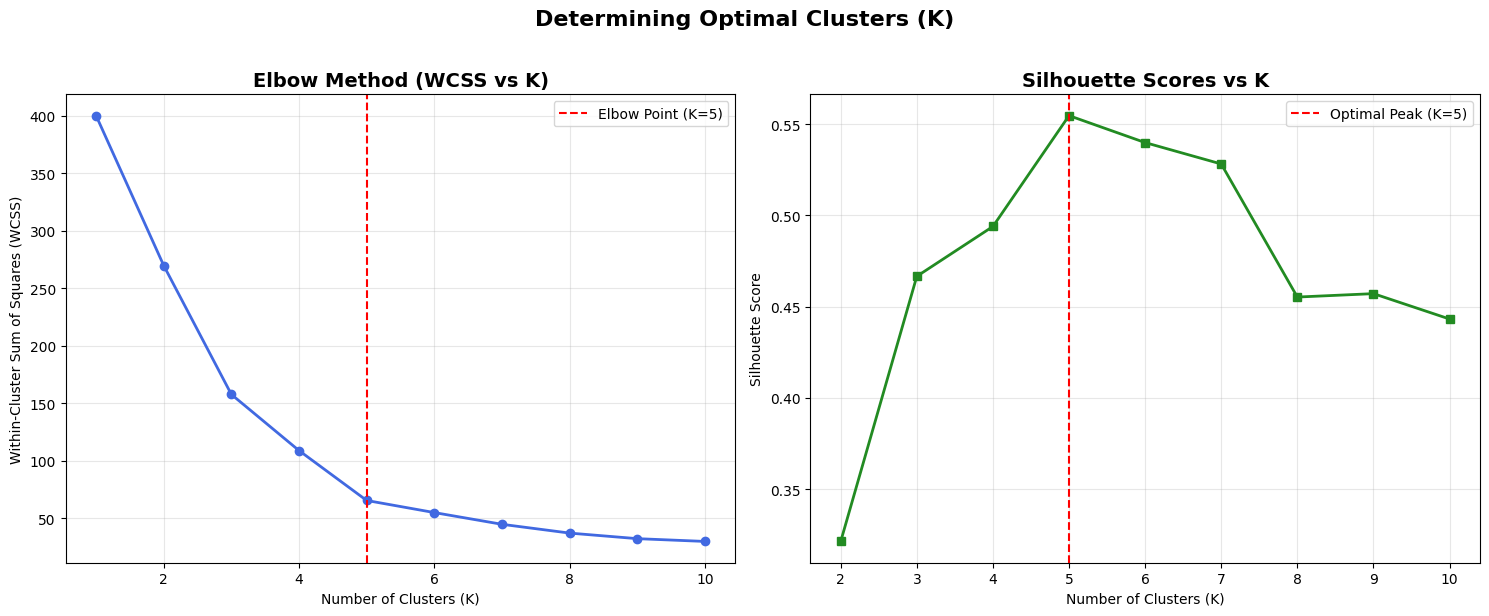

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# elbow method plot
axes[0].plot(range(1, 11), wcss_k1_10, marker='o', color='royalblue', lw=2)
axes[0].axvline(5, color='red', linestyle='--', label='Elbow Point (K=5)')
axes[0].set_title('Elbow Method (WCSS vs K)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# silhouette score plot
axes[1].plot(range(2, 11), silhouette_scores, marker='s', color='forestgreen', lw=2)
axes[1].axvline(5, color='red', linestyle='--', label='Optimal Peak (K=5)')
axes[1].set_title('Silhouette Scores vs K', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Determining Optimal Clusters (K)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('clustering_optimization_curves.png', bbox_inches='tight', dpi=150)
plt.show()


## step 7 - compare clustering quality across different K values

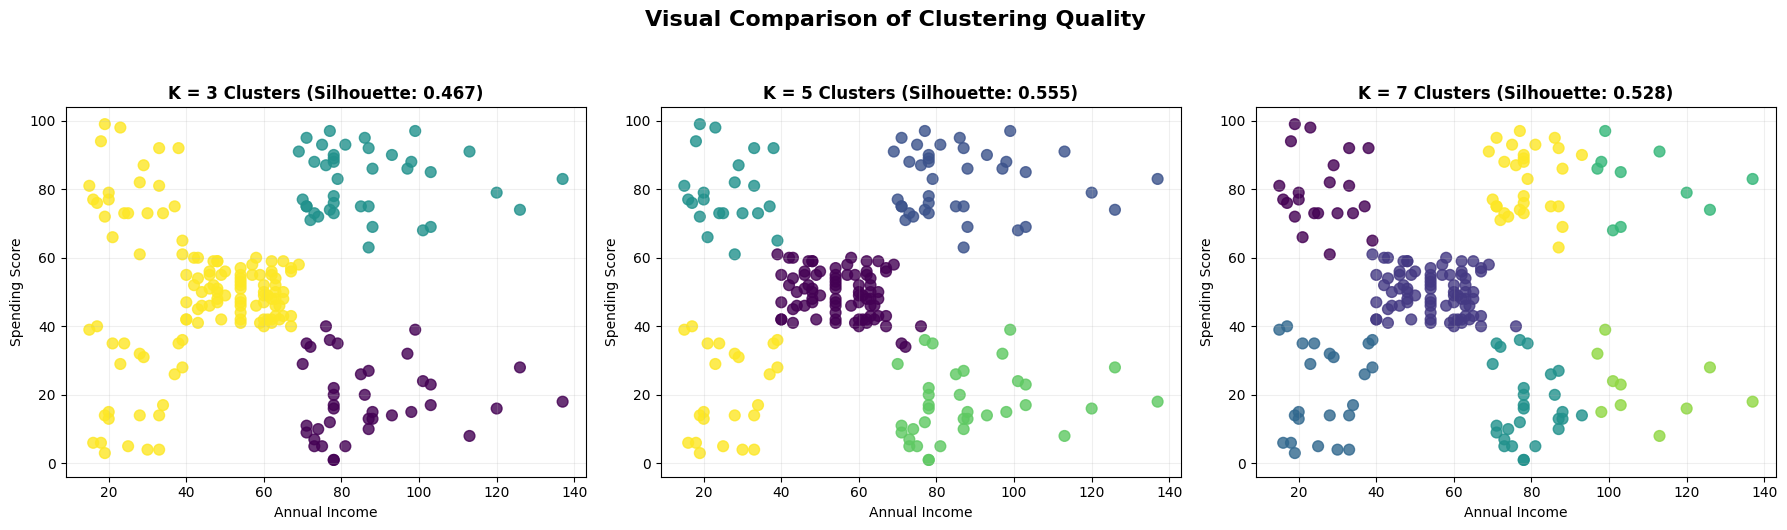

In [7]:
compare_k = [3, 5, 7]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, k in enumerate(compare_k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # plot
    scatter = axes[i].scatter(
        df['Annual Income (k$)'],
        df['Spending Score (1-100)'],
        c=labels,
        cmap='viridis',
        s=60,
        alpha=0.8
    )
    axes[i].set_title(f'K = {k} Clusters (Silhouette: {silhouette_score(X_scaled, labels):.3f})', 
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Annual Income')
    axes[i].set_ylabel('Spending Score')
    axes[i].grid(alpha=0.2)

plt.suptitle('Visual Comparison of Clustering Quality', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('clustering_comparison_k.png', bbox_inches='tight', dpi=150)
plt.show()


## step 8 - apply optimal K-Means (K=5)

In [8]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Distribution of customers across clusters:")
print(df['Cluster'].value_counts())


Distribution of customers across clusters:
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


## step 9 - analyze cluster averages and document strategy

In [9]:
cluster_profile = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_profile['Customer Count'] = df['Cluster'].value_counts()
print("Cluster Profiles (Mean values):")
print(cluster_profile.round(2))


Cluster Profiles (Mean values):
         Annual Income (k$)  Spending Score (1-100)  Customer Count
Cluster                                                            
0                     55.30                   49.52              81
1                     86.54                   82.13              39
2                     25.73                   79.36              22
3                     88.20                   17.11              35
4                     26.30                   20.91              23


### business segmentation strategy based on optimal K=5:
- **Cluster 0:** Standard customer. Mid income, mid spend. Good baseline.
- **Cluster 1:** VIP/Target customer. High income, high spend. Focus area for premium loyalty programs.
- **Cluster 2:** Impetuous customer. Low income, high spend. Target with trendy, budget-friendly impulse offers.
- **Cluster 3:** Careful customer. High income, low spend. Target with value-driven campaigns or exclusive product features.
- **Cluster 4:** Sensible customer. Low income, low spend. Keep marketing costs low, focus on value/necessities.
